# Section 1 — Kaggle Setup & Imports

In [2]:
# ── KAGGLE SETUP: Download ADNI dataset from Google Drive ───────────
import os, subprocess
from pathlib import Path

GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')
ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'

if not os.path.exists(WORK_DIR / 'CN'):
    print('📦 Step 1/3: Installing gdown...')
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    print('⬇️  Step 2/3: Downloading ADNI dataset...')
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)
    print('📂 Step 3/3: Extracting...')
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink()
    print('✅ Done!')

ADNI_DIR = str(WORK_DIR)
for root, dirs, files in os.walk(WORK_DIR):
    if 'CN' in dirs and 'MCI' in dirs and 'AD' in dirs:
        ADNI_DIR = root
        break
print(f"ADNI_DIR = {ADNI_DIR}")

📦 Step 1/3: Installing gdown...
⬇️  Step 2/3: Downloading ADNI dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz
From (redirected): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz&confirm=t&uuid=e1f0a406-5137-4956-94e0-cbd57accf3a0
To: /kaggle/working/adni_dataset.zip
100%|██████████| 387M/387M [00:03<00:00, 119MB/s]  


📂 Step 3/3: Extracting...
✅ Done!
ADNI_DIR = /kaggle/working/adni_nifti_preprocessed


In [3]:
import os, csv, random, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Section 2 — Configuration

In [4]:
DATA_ROOT  = ADNI_DIR
OUTPUT_DIR = "/kaggle/working/preprocessed"
CKPT_DIR   = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE   = 224
N_FOLDS      = 5
BATCH_SIZE   = 32
NUM_EPOCHS   = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
PATIENCE     = 10
GRAD_CLIP    = 1.0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")

Classes found: ['AD', 'CN', 'MCI']


# Section 3 — Build Patient Map & Leakage Check

In [5]:
patient_classes = defaultdict(set)
patient_slices  = defaultdict(list)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir): continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir): continue
        slices = [os.path.join(patient_dir, f) for f in os.listdir(patient_dir)
                  if os.path.splitext(f)[1].lower() in VALID_EXTS]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f"Total unique patients: {len(patient_classes)}")

leakage_patients = {pid: c for pid, c in patient_classes.items() if len(c) > 1}
print(f"\n{'='*55}\n  LEAKAGE CHECK\n{'='*55}")
if leakage_patients:
    print(f"  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}")
else:
    print("  No patients in multiple classes. Dataset is clean.")

clean_patients = {pid: list(c)[0] for pid, c in patient_classes.items() if pid not in leakage_patients}
print(f"\n  Patients kept: {len(clean_patients)}  |  Excluded: {len(leakage_patients)}")

Total unique patients: 320

  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept: 320  |  Excluded: 0


# Section 4 — Hold-Out Test Set (Patient-Level, Stratified)

In [6]:
TEST_RATIO = 0.10
class_patients_map = defaultdict(list)
for pid, cls in clean_patients.items():
    class_patients_map[cls].append(pid)
for cls in CLASS_NAMES:
    random.shuffle(class_patients_map[cls])

test_patients = []; trainval_patients = []
print(f"{'='*55}\n  HOLD-OUT TEST SET\n{'='*55}")
for cls in CLASS_NAMES:
    pids = class_patients_map[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test])
    trainval_patients.extend(pids[n_test:])
    print(f"  {cls}: {len(pids)} total | test={n_test} | trainval={len(pids)-n_test}")

assert not (set(test_patients) & set(trainval_patients)), "Overlap!"
test_entries = []
for pid in test_patients:
    cls = clean_patients[pid]; label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        test_entries.append((path, label, pid))
print(f"\n  Test patients: {len(test_patients)}  |  TrainVal: {len(trainval_patients)}")
print(f"  Test slices: {len(test_entries)}")

  HOLD-OUT TEST SET
  AD: 54 total | test=5 | trainval=49
  CN: 88 total | test=8 | trainval=80
  MCI: 178 total | test=17 | trainval=161

  Test patients: 30  |  TrainVal: 290
  Test slices: 802


# Section 5 — Preprocess & Save Slices

In [7]:
if os.path.exists(OUTPUT_DIR): shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        all_entries.append((path, label, pid))

fname_counts = {}
def preprocess_and_save(entries, desc="Saving"):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(path))[0]
        key = f"{pid}_{base}"
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix = f"_dup{fname_counts[key]}" if fname_counts[key] > 1 else ""
        out_path = os.path.join(out_dir, f"{key}{suffix}.pt")
        if not os.path.exists(out_path):
            img = Image.open(path).convert("RGB")
            tensor = transforms.ToTensor()(img)
            tensor = (tensor * 255).byte()
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc="Preprocessing all slices")
print(f"Done. {len(all_entries)} slices saved.")

pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir): continue
    for fname in os.listdir(cls_dir):
        if fname.endswith(".pt"):
            pt_lookup[fname[:-3]] = os.path.join(cls_dir, fname)
print(f"pt_lookup: {len(pt_lookup)} entries")

Preprocessing all slices: 100%|██████████| 8512/8512 [00:20<00:00, 420.82it/s]

Done. 8512 slices saved.
pt_lookup: 8512 entries


# Section 6 — Dataset Class & ResNet50 Model

In [8]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

class SliceDataset(Dataset):
    def __init__(self, entries, augment=False):
        self.samples = []; self.augment = augment
        for path, label, pid in entries:
            base = os.path.splitext(os.path.basename(path))[0]
            key = f"{pid}_{base}"
            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                for di in range(2, 50):
                    dk = f"{key}_dup{di}"
                    if dk in pt_lookup:
                        self.samples.append((pt_lookup[dk], label, pid))
                        break
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        tensor = torch.load(pt_path, weights_only=True).float() / 255.0
        if self.augment: tensor = train_augment(tensor)
        return normalize(tensor), label, pid
    def get_labels(self): return [s[1] for s in self.samples]

def build_resnet50(num_classes=2):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(512, num_classes)
    )
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  ResNet50: {trainable:,} trainable / {total:,} total params ({trainable/total*100:.1f}%)")
    return model

print("Dataset class and model builder defined.")

Dataset class and model builder defined.


# Section 7 — Training Utilities

In [9]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with (torch.enable_grad() if is_train else torch.no_grad()):
        for batch in tqdm(loader, desc=desc, leave=False):
            images, labels, _ = batch
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
            correct += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
    return total_loss / total, correct / total

def patient_level_eval(loader, model, binary_names):
    model.eval()
    patient_probs = defaultdict(list)
    patient_labels = {}
    with torch.no_grad():
        for images, labels, pids in tqdm(loader, desc="Patient-eval", leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda"):
                logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            for prob, label, pid in zip(probs, labels.numpy(), pids):
                patient_probs[pid].append(prob)
                patient_labels[pid] = int(label)
    all_true, all_pred = [], []
    for pid, probs_list in patient_probs.items():
        avg_prob = np.mean(probs_list, axis=0)
        all_true.append(patient_labels[pid])
        all_pred.append(int(np.argmax(avg_prob)))
    acc = np.mean(np.array(all_true) == np.array(all_pred))
    return acc, all_true, all_pred

print("Training utilities defined.")

Training utilities defined.


# Section 8 — K-Fold Cross-Validation (1-vs-All)

In [10]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)
for cls in CLASS_NAMES:
    random.shuffle(trainval_by_class[cls])

fold_results    = {cls: [] for cls in CLASS_NAMES}
all_fold_ckpts  = {cls: [] for cls in CLASS_NAMES}
all_fold_models = {cls: [] for cls in CLASS_NAMES}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print(f"\n{'='*65}")
    print(f"  {pos_name} vs REST — {N_FOLDS}-Fold Cross-Validation")
    print(f"{'='*65}")
    binary_names = ["REST", pos_name]
    class_folds = {}
    for cls in CLASS_NAMES:
        pids = trainval_by_class[cls]
        class_folds[cls] = [pids[i::N_FOLDS] for i in range(N_FOLDS)]

    for fold_idx in range(N_FOLDS):
        print(f"\n  --- Fold {fold_idx+1}/{N_FOLDS} ---")
        val_pids = []; train_pids = []
        for cls in CLASS_NAMES:
            val_pids.extend(class_folds[cls][fold_idx])
            for k, chunk in enumerate(class_folds[cls]):
                if k != fold_idx: train_pids.extend(chunk)

        def expand(pids):
            out = []
            for pid in pids:
                cls = clean_patients[pid]; label = CLASS_NAMES.index(cls)
                for path in patient_slices[(pid, cls)]:
                    out.append((path, label, pid))
            return out

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in entries]

        train_bin = binarize(expand(train_pids))
        val_bin   = binarize(expand(val_pids))
        train_ds = SliceDataset(train_bin, augment=True)
        val_ds   = SliceDataset(val_bin, augment=False)

        pos_count = sum(1 for _, l, _ in train_bin if l == 1)
        neg_count = len(train_bin) - pos_count
        print(f"  Train: {pos_name}={pos_count} REST={neg_count} | Val patients: {len(val_pids)}")

        if len(train_ds) == 0:
            raise RuntimeError(f"Fold {fold_idx+1} ({pos_name}): empty dataset!")

        cls_counts = Counter(train_ds.get_labels())
        weights = [1.0 / cls_counts[l] for l in train_ds.get_labels()]
        sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                  num_workers=4, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True, persistent_workers=True)

        model = build_resnet50(num_classes=2).to(device)
        criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
        scaler = torch.amp.GradScaler()
        ckpt_path        = os.path.join(CKPT_DIR, f"fold{fold_idx+1}_{pos_name}_vs_rest.pt")
        ckpt_path_latest = os.path.join(CKPT_DIR, f"fold{fold_idx+1}_{pos_name}_vs_rest_RESUME.pt")

        # ── SKIP: fold already fully finished ────────────────────────
        if os.path.exists(ckpt_path) and not os.path.exists(ckpt_path_latest):
            print(f"  [SKIP] Fold {fold_idx+1} {pos_name} already done. Loading checkpoint.")
            model.load_state_dict(torch.load(ckpt_path, map_location=device))
            pat_acc, _, _ = patient_level_eval(val_loader, model, binary_names)
            print(f"  Fold {fold_idx+1} — Patient-level val acc: {pat_acc*100:.2f}%")
            fold_results[pos_name].append(pat_acc)
            all_fold_ckpts[pos_name].append(ckpt_path)
            model.to("cpu"); model.eval()
            all_fold_models[pos_name].append(model)
            del train_ds, val_ds
            torch.cuda.empty_cache()
            continue

        # ── RESUME: interrupted mid-fold ─────────────────────────────
        best_val_loss, patience_ctr, start_epoch = float('inf'), 0, 1
        if os.path.exists(ckpt_path_latest):
            print(f"  [RESUME] Restoring full training state for {pos_name} Fold {fold_idx+1}...")
            resume_ckpt = torch.load(ckpt_path_latest, map_location=device)
            model.load_state_dict(resume_ckpt['model_state_dict'])
            optimizer.load_state_dict(resume_ckpt['optimizer_state_dict'])
            scheduler.load_state_dict(resume_ckpt['scheduler_state_dict'])
            scaler.load_state_dict(resume_ckpt['scaler_state_dict'])
            best_val_loss = resume_ckpt['best_val_loss']
            patience_ctr  = resume_ckpt['patience_ctr']
            start_epoch   = resume_ckpt['epoch'] + 1
            print(f"  -> Resuming from Epoch {start_epoch}, LR={optimizer.param_groups[0]['lr']:.2e}")

        for epoch in range(start_epoch, NUM_EPOCHS + 1):
            tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer, scaler,
                                        desc=f"Ep{epoch}/{NUM_EPOCHS} [train]")
            vl_loss, vl_acc = run_epoch(val_loader, model, criterion,
                                        desc=f"Ep{epoch}/{NUM_EPOCHS} [val]")
            scheduler.step(vl_loss)
            cur_lr = optimizer.param_groups[0]['lr']
            print(f"  Ep {epoch:02d} | train loss={tr_loss:.4f} acc={tr_acc*100:.1f}% | "
                  f"val loss={vl_loss:.4f} acc={vl_acc*100:.1f}% | lr={cur_lr:.2e}")
            if vl_loss < best_val_loss:
                best_val_loss = vl_loss
                torch.save(model.state_dict(), ckpt_path)
                patience_ctr = 0
                print(f"    ✓ Best val_loss={best_val_loss:.4f} (acc={vl_acc*100:.2f}%) — saved.")
            else:
                patience_ctr += 1

            # ── Save full state after every epoch for crash recovery ──
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict':    scaler.state_dict(),
                'best_val_loss':        best_val_loss,
                'patience_ctr':         patience_ctr,
            }, ckpt_path_latest)

            if patience_ctr >= PATIENCE:
                print(f"    Early stopping at epoch {epoch}.")
                break

        if os.path.exists(ckpt_path_latest):
            os.remove(ckpt_path_latest)

        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        pat_acc, _, _ = patient_level_eval(val_loader, model, binary_names)
        print(f"  Fold {fold_idx+1} — Patient-level val acc: {pat_acc*100:.2f}%")

        fold_results[pos_name].append(pat_acc)
        all_fold_ckpts[pos_name].append(ckpt_path)
        model.to("cpu"); model.eval()
        all_fold_models[pos_name].append(model)

        del optimizer, scaler, train_ds, val_ds
        torch.cuda.empty_cache()

    mean_acc = np.mean(fold_results[pos_name]) * 100
    std_acc  = np.std(fold_results[pos_name]) * 100
    print(f"\n  {pos_name} vs REST — {N_FOLDS}-Fold CV: {mean_acc:.2f}% ± {std_acc:.2f}%")

print("\n\nAll folds done.")


  AD vs REST — 5-Fold Cross-Validation

  --- Fold 1/5 ---
  Train: AD=1036 REST=5098 | Val patients: 59
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s] 


  ResNet50: 1,054,210 trainable / 24,562,242 total params (4.3%)


  Ep 01 | train loss=0.6530 acc=68.3% | val loss=0.6672 acc=65.6% | lr=1.00e-03
    ✓ Best val_loss=0.6672 (acc=65.61%) — saved.


  Ep 02 | train loss=0.5704 acc=74.1% | val loss=0.5746 acc=75.5% | lr=1.00e-03
    ✓ Best val_loss=0.5746 (acc=75.51%) — saved.


...

  Ep 08 | train loss=0.5686 acc=73.1% | val loss=0.7758 acc=52.6% | lr=5.00e-04


  Ep 09 | train loss=0.5519 acc=74.6% | val loss=0.8218 acc=48.5% | lr=2.50e-04


  Ep 10 | train loss=0.5399 acc=76.5% | val loss=0.8074 acc=51.6% | lr=2.50e-04


  Ep 11 | train loss=0.5286 acc=76.9% | val loss=0.7914 acc=53.0% | lr=2.50e-04
    Early stopping at epoch 11.


  Fold 5 — Patient-level val acc: 50.88%

  MCI vs REST — 5-Fold CV: 54.17% ± 9.91%


All folds done.


# Section 9 — Weighted Ensemble Test Evaluation

  WEIGHTED ENSEMBLE — HOLD-OUT TEST (Patient-Level)

  AD vs REST
    Fold 1: val_acc=83.05%  weight=0.2103
    Fold 2: val_acc=72.41%  weight=0.1834
    Fold 3: val_acc=74.14%  weight=0.1878
    Fold 4: val_acc=81.03%  weight=0.2052
    Fold 5: val_acc=84.21%  weight=0.2133



  Ensemble Test Acc (AD vs REST): 83.33%
              precision    recall  f1-score   support

        REST       0.86      0.96      0.91        25
          AD       0.50      0.20      0.29         5

    accuracy                           0.83        30
   macro avg       0.68      0.58      0.60        30
weighted avg       0.80      0.83      0.80        30



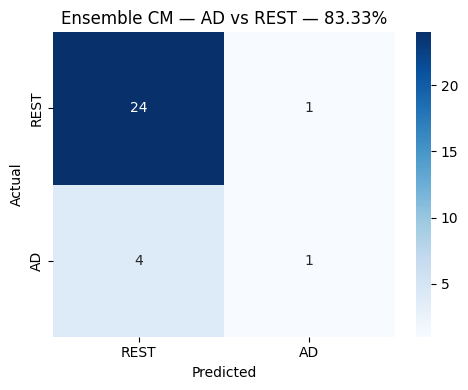


  CN vs REST
    Fold 1: val_acc=64.41%  weight=0.1762
    Fold 2: val_acc=72.41%  weight=0.1981
    Fold 3: val_acc=77.59%  weight=0.2122
    Fold 4: val_acc=81.03%  weight=0.2216
    Fold 5: val_acc=70.18%  weight=0.1919



  Ensemble Test Acc (CN vs REST): 80.00%
              precision    recall  f1-score   support

        REST       0.86      0.86      0.86        22
          CN       0.62      0.62      0.62         8

    accuracy                           0.80        30
   macro avg       0.74      0.74      0.74        30
weighted avg       0.80      0.80      0.80        30



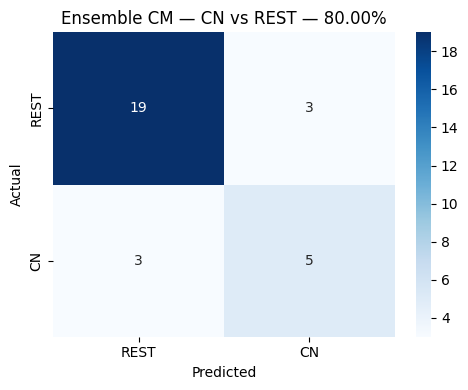


  MCI vs REST
    Fold 1: val_acc=40.68%  weight=0.1502
    Fold 2: val_acc=48.28%  weight=0.1782
    Fold 3: val_acc=63.79%  weight=0.2355
    Fold 4: val_acc=67.24%  weight=0.2482
    Fold 5: val_acc=50.88%  weight=0.1878



  Ensemble Test Acc (MCI vs REST): 60.00%
              precision    recall  f1-score   support

        REST       0.55      0.46      0.50        13
         MCI       0.63      0.71      0.67        17

    accuracy                           0.60        30
   macro avg       0.59      0.58      0.58        30
weighted avg       0.59      0.60      0.59        30



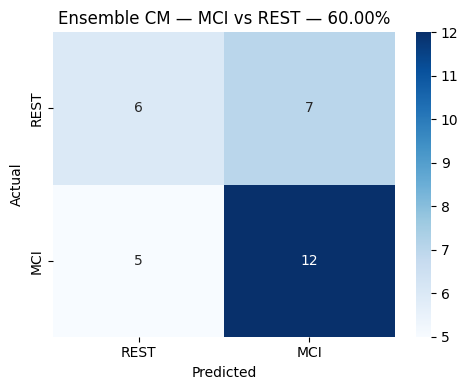

In [11]:
print(f"{'='*65}")
print(f"  WEIGHTED ENSEMBLE — HOLD-OUT TEST (Patient-Level)")
print(f"{'='*65}")
final_results = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    binary_names = ["REST", pos_name]
    test_bin = [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in test_entries]
    test_ds = SliceDataset(test_bin, augment=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, pin_memory=True, persistent_workers=True)

    fold_accs = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()
    print(f"\n  {pos_name} vs REST")
    for fi, (acc, w) in enumerate(zip(fold_accs, fold_weights)):
        print(f"    Fold {fi+1}: val_acc={acc*100:.2f}%  weight={w:.4f}")

    fold_models_list = all_fold_models[pos_name]
    for m in fold_models_list: m.to(device); m.eval()

    patient_probs = defaultdict(lambda: np.zeros(2))
    patient_labels = {}
    with torch.no_grad():
        for images, labels, pids in tqdm(test_loader, desc=f"{pos_name} Ensemble", leave=False):
            images = images.to(device, non_blocking=True)
            batch_wp = np.zeros((images.size(0), 2))
            for fm, w in zip(fold_models_list, fold_weights):
                with torch.amp.autocast(device_type="cuda"):
                    logits = fm(images)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                batch_wp += w * probs
            for wp, label, pid in zip(batch_wp, labels.numpy(), pids):
                patient_probs[pid] += wp
                patient_labels[pid] = int(label)

    all_true, all_pred = [], []
    for pid, wp_sum in patient_probs.items():
        all_true.append(patient_labels[pid])
        all_pred.append(int(np.argmax(wp_sum)))

    pat_acc = np.mean(np.array(all_true) == np.array(all_pred))
    print(f"\n  Ensemble Test Acc ({pos_name} vs REST): {pat_acc*100:.2f}%")
    print(classification_report(all_true, all_pred, target_names=binary_names))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=binary_names, yticklabels=binary_names)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Ensemble CM — {pos_name} vs REST — {pat_acc*100:.2f}%")
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"cm_ensemble_{pos_name}_vs_rest.png"), dpi=150)
    plt.show()

    final_results[pos_name] = {
        "patient_test_acc": pat_acc,
        "cv_mean_acc": float(np.mean(fold_accs)),
        "cv_std_acc": float(np.std(fold_accs)),
    }
    for m in fold_models_list: m.to("cpu")
    torch.cuda.empty_cache()

# Section 10 — Summary & Results

In [12]:
print(f"\n{'='*65}")
print(f"  FINAL SUMMARY")
print(f"{'='*65}")
print(f"  {'Class':<8} {'CV Acc (mean±std)':<24} {'Ensemble Test Acc'}")
print(f"  {'-'*65}")
for cls, res in final_results.items():
    cv_str = f"{res['cv_mean_acc']*100:.2f}% ± {res['cv_std_acc']*100:.2f}%"
    test_str = f"{res['patient_test_acc']*100:.2f}%"
    print(f"  {cls:<8} {cv_str:<24} {test_str}")

csv_path = os.path.join(CKPT_DIR, "results.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["class","cv_mean_%","cv_std_%","test_acc_%"])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({
            "class": cls,
            "cv_mean_%": round(res["cv_mean_acc"]*100, 2),
            "cv_std_%": round(res["cv_std_acc"]*100, 2),
            "test_acc_%": round(res["patient_test_acc"]*100, 2),
        })
print(f"\n  Results saved → {csv_path}")


  FINAL SUMMARY
  Class    CV Acc (mean±std)        Ensemble Test Acc
  -----------------------------------------------------------------
  AD       78.97% ± 4.79%           83.33%
  CN       73.12% ± 5.79%           80.00%
  MCI      54.17% ± 9.91%           60.00%

  Results saved → /kaggle/working/checkpoints/results.csv


In [13]:
import json

ensemble_meta = {}
for pos_name in CLASS_NAMES:
    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = (fold_accs / fold_accs.sum()).tolist()
    ensemble_meta[pos_name] = {
        "fold_ckpt_paths": all_fold_ckpts[pos_name],
        "fold_val_accs":   fold_accs.tolist(),
        "fold_weights":    fold_weights,
    }

meta_path = os.path.join(CKPT_DIR, "ensemble_meta.json")
with open(meta_path, "w") as f:
    json.dump(ensemble_meta, f, indent=2)

print(f"Saved → {meta_path}")

Saved → /kaggle/working/checkpoints/ensemble_meta.json


In [14]:
!pip install grad-cam lime shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.1 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [23]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
import shap
import os
import random
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

def normalize_image(image_array):
    img = np.array(image_array, dtype=np.float32)
    img = img - np.min(img)
    if np.max(img) > 0: img = img / np.max(img)
    return img

def convert_to_rgb(image_array):
    if len(image_array.shape) == 2: return np.stack([image_array] * 3, axis=-1)
    elif image_array.shape[0] == 3: return np.transpose(image_array, (1, 2, 0))
    return image_array

def create_colormap_overlay(heatmap, image_array, alpha=0.4):
    heatmap = normalize_image(heatmap)
    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2: image_array = convert_to_rgb(image_array)
    heatmap_colored = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    return (1 - alpha) * image_array + alpha * heatmap_colored

def compute_gradcam(model, image_tensor, target_class, device='cuda'):
    model.eval()
    for param in model.parameters(): param.requires_grad = True
    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    cam = GradCAM(model=model, target_layers=[conv_layers[-1]])
    grayscale_cam = cam(input_tensor=image_tensor.to(device), targets=[ClassifierOutputTarget(target_class)], eigen_smooth=False, aug_smooth=False)
    with torch.no_grad():
        output = model(image_tensor.to(device))
        pred_prob = torch.softmax(output, dim=1)[0, target_class].item()
        pred_class = output.argmax(dim=1).item()
    return grayscale_cam[0], pred_class, pred_prob

def visualize_gradcam(image_array, grayscale_cam, pred_class, pred_prob, target_class, class_names, title):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    image_array = convert_to_rgb(normalize_image(image_array))
    grayscale_cam = normalize_image(grayscale_cam)
    axes[0].imshow(image_array); axes[0].set_title('Original Image'); axes[0].axis('off')
    im = axes[1].imshow(grayscale_cam, cmap='hot'); axes[1].set_title('Grad-CAM Heatmap'); axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    axes[2].imshow(create_colormap_overlay(grayscale_cam, image_array, alpha=0.5))
    axes[2].set_title(f'Overlay (Target: {class_names[target_class]}, Pred: {class_names[pred_class]} {pred_prob:.2%})')
    axes[2].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold'); plt.tight_layout()
    return fig

def compute_lime_explanation(model, image_array, target_class, device='cuda'):
    model.eval()
    image_array = convert_to_rgb(normalize_image(image_array))
    def predict_fn(images):
        imgs = torch.from_numpy(images).float().permute(0, 3, 1, 2).to(device)
        with torch.no_grad(): return torch.softmax(model(imgs), dim=1).cpu().numpy()
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(image_array, predict_fn, labels=[target_class], num_samples=500)
    image_and_mask = explanation.get_image_and_mask(label=target_class, positive_only=False, num_features=5, hide_rest=False)
    return explanation, image_and_mask

def visualize_lime(image_array, explanation, image_and_mask, target_class, class_names, title):
    image_array = convert_to_rgb(normalize_image(image_array))
    image, mask = image_and_mask
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image_array); axes[0].set_title('Original Image'); axes[0].axis('off')
    pos_image, _ = explanation.get_image_and_mask(target_class, positive_only=True, hide_rest=False)
    axes[1].imshow(mark_boundaries(pos_image, mask)); axes[1].set_title(f'LIME Supporting Regions ({class_names[target_class]})'); axes[1].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold'); plt.tight_layout()
    return fig

In [57]:
print("Extracting random images...")

if 'xai_samples' not in globals():
    xai_samples = {}

# ==========================================
RE_ROLL_CLASSES = ["MCI"] 
# ==========================================

import random
for cls_name in RE_ROLL_CLASSES:
    cls_idx = CLASS_NAMES.index(cls_name)
    
    cls_entries = [e for e in test_entries if e[1] == cls_idx]
    
    path, label, pid = random.choice(cls_entries)
    
    img_pil = Image.open(path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    img_tensor = normalize(transforms.ToTensor()(img_pil).unsqueeze(0).to(device))
    
    xai_samples[label] = (img_tensor, img_tensor[0].cpu().numpy())
    print(f"✅ Rolled a new image for: {cls_name}")

if 'bg' not in globals():
    from torch.utils.data import DataLoader as DL
    fresh_train_loader = DL(train_loader.dataset, batch_size=16, shuffle=True, num_workers=0)
    xb, _, _ = next(iter(fresh_train_loader))
    bg = xb.to(device).float()
    if bg.size(0) < 2: bg = torch.cat([bg, bg], dim=0)

print(f"\nReady! Current saved images: {[CLASS_NAMES[k] for k in xai_samples.keys()]}")

Extracting random images...
✅ Rolled a new image for: MCI

Ready! Current saved images: ['MCI', 'AD', 'CN']



1. Grad-CAM (Explaining the ResNet50)

--- Grad-CAM Class: AD ---


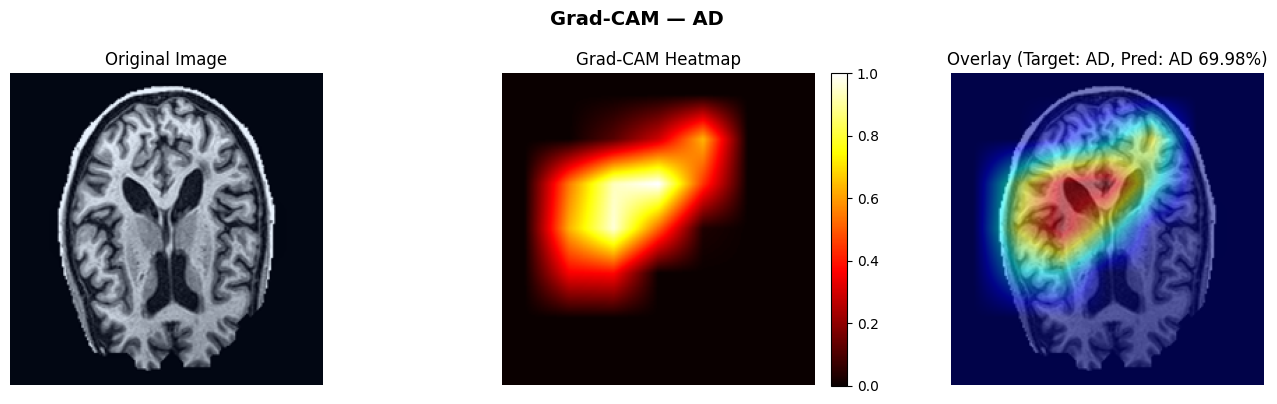


--- Grad-CAM Class: CN ---


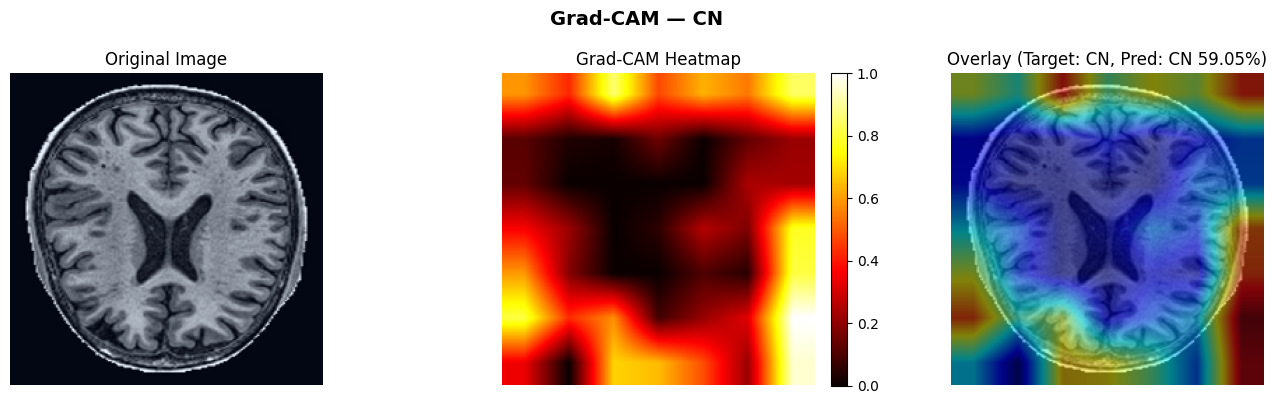


--- Grad-CAM Class: MCI ---


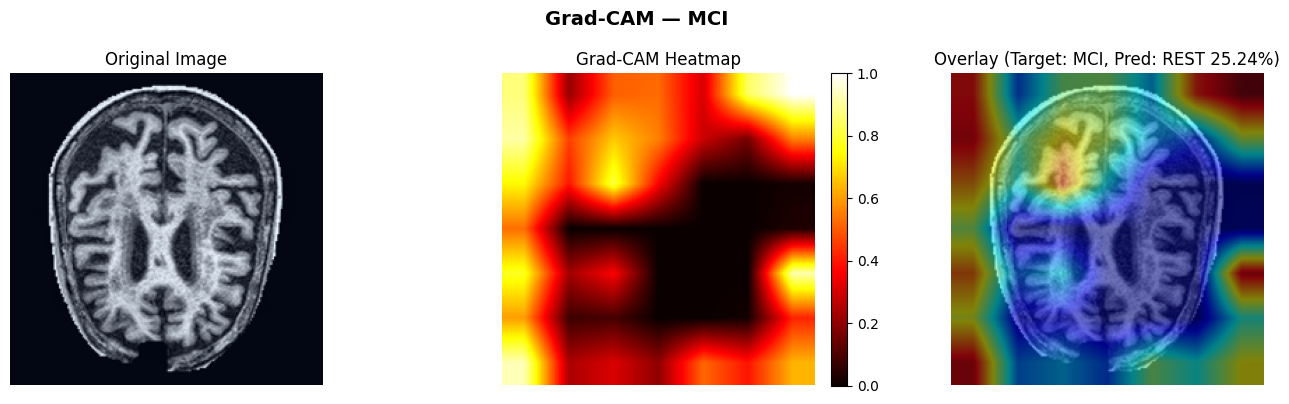

In [58]:
print("\n" + "="*60)
print("1. Grad-CAM (Explaining the ResNet50)")
print("="*60)

for cls_name in CLASS_NAMES:
    cls_idx = CLASS_NAMES.index(cls_name)
    img_tensor, img_array = xai_samples[cls_idx]
    model = all_fold_models[cls_name][0].to(device)
    
    print(f'\n--- Grad-CAM Class: {cls_name} ---')
    cam, pred_class, pred_prob = compute_gradcam(model, img_tensor, 1, device)
    fig = visualize_gradcam(img_array, cam, pred_class, pred_prob, 1, ["REST", cls_name], f'Grad-CAM — {cls_name}')
    plt.show()
    model.to('cpu'); torch.cuda.empty_cache()


2. LIME (Explaining the ResNet50)

--- LIME Class: AD ---


  0%|          | 0/500 [00:00<?, ?it/s]

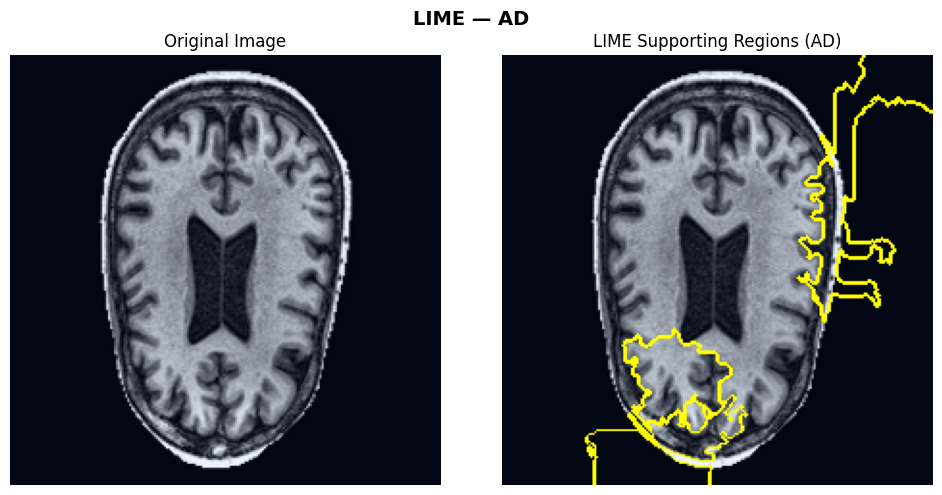


--- LIME Class: CN ---


  0%|          | 0/500 [00:00<?, ?it/s]

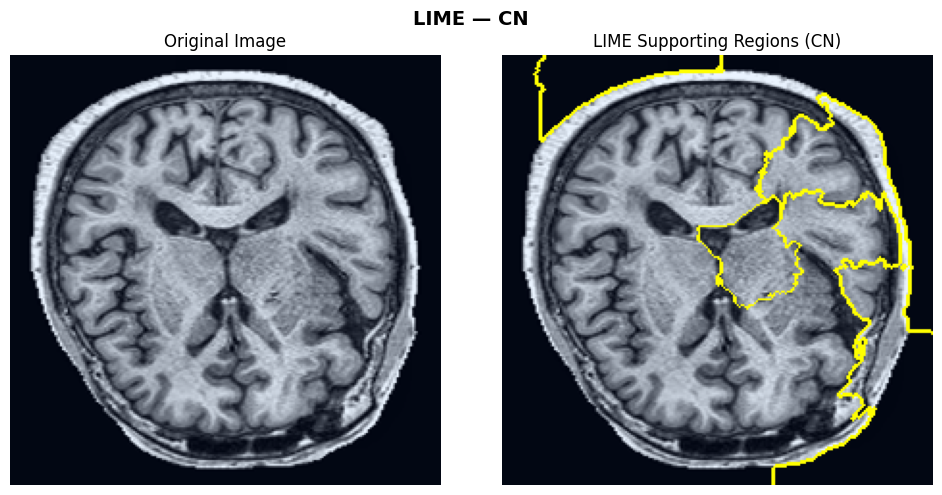


--- LIME Class: MCI ---


  0%|          | 0/500 [00:00<?, ?it/s]

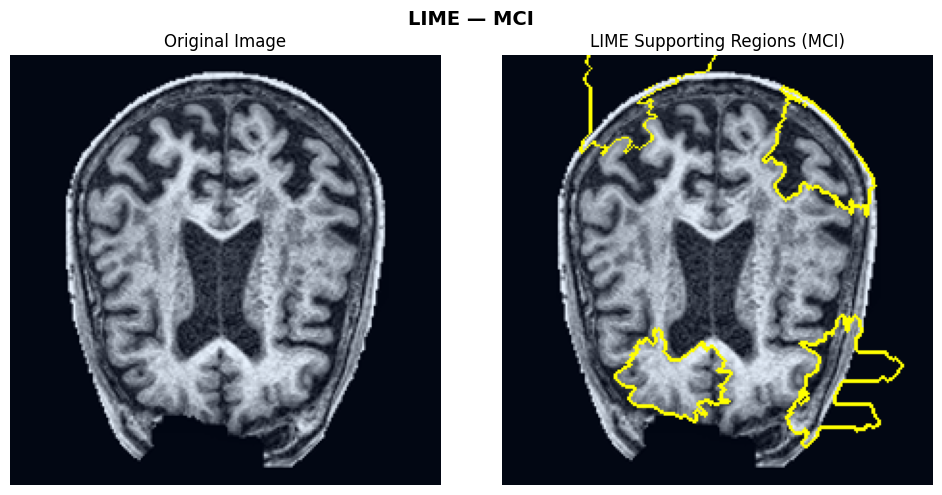

In [18]:
print("\n" + "="*60)
print("2. LIME (Explaining the ResNet50)")
print("="*60)

for cls_name in CLASS_NAMES:
    cls_idx = CLASS_NAMES.index(cls_name)
    img_tensor, img_array = xai_samples[cls_idx]
    model = all_fold_models[cls_name][0].to(device)
    
    print(f'\n--- LIME Class: {cls_name} ---')
    explanation, img_and_mask = compute_lime_explanation(model, img_array, 1, device)
    fig = visualize_lime(img_array, explanation, img_and_mask, 1, ["REST", cls_name], f'LIME — {cls_name}')
    plt.show()
    model.to('cpu'); torch.cuda.empty_cache()


3. SHAP on Brain Images (Explaining the ResNet50)
  AD | img shape: (224, 224, 3) | SHAP shape: (224, 2)


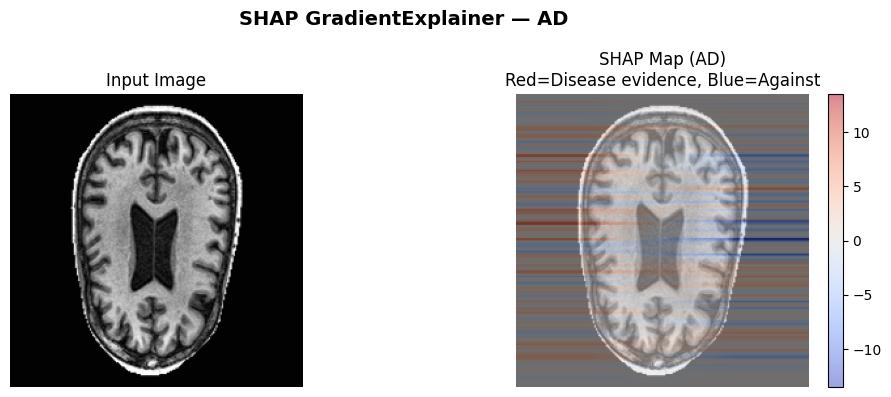

  CN | img shape: (224, 224, 3) | SHAP shape: (224, 2)


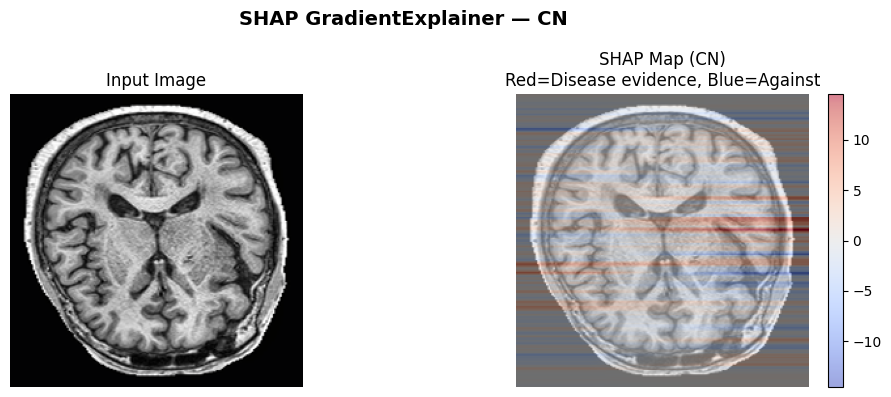

  MCI | img shape: (224, 224, 3) | SHAP shape: (224, 2)


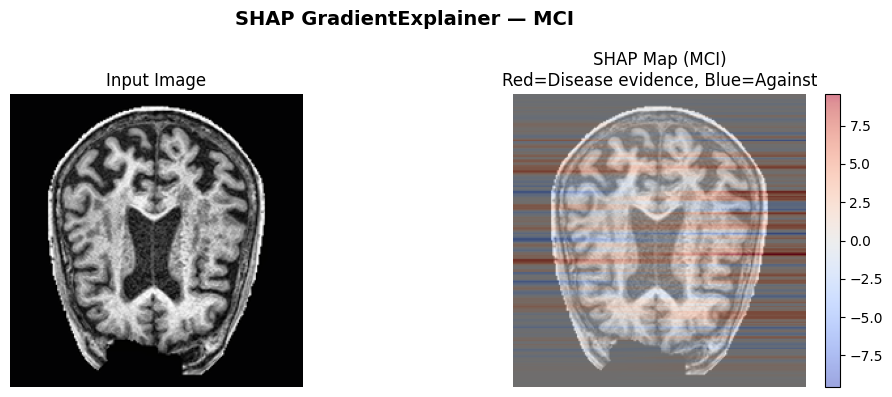

In [19]:
print("\n" + "="*60)
print("3. SHAP on Brain Images (Explaining the ResNet50)")
print("="*60)

for cls_name in CLASS_NAMES:
    cls_idx = CLASS_NAMES.index(cls_name)
    img_tensor, _ = xai_samples[cls_idx]
    model = all_fold_models[cls_name][0].to(device).eval()
    
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img0 = img_tensor[0].detach().cpu().numpy()
    img_rgb = np.clip(np.transpose(img0 * std + mean, (1, 2, 0)), 0, 1)
    H, W = img_rgb.shape[:2]
    
    try:
        xt = img_tensor.clone().detach().requires_grad_(True)
        sv = shap.GradientExplainer(model, bg).shap_values(xt)
        
        smap = np.asarray(sv[1][0] if isinstance(sv, list) else sv[0])
        if smap.ndim == 4: smap = smap[0]
        
        imp = smap.sum(axis=0)
        
        print(f"  {cls_name} | img shape: {img_rgb.shape} | SHAP shape: {imp.shape}")
        
        imp_resized = cv2.resize(imp.astype(np.float32), (W, H), interpolation=cv2.INTER_LINEAR)
        vmax = np.abs(imp_resized).max() + 1e-8
        
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].imshow(img_rgb)
        ax[0].set_title('Input Image')
        ax[0].axis('off')
        
        ax[1].imshow(img_rgb)
        shap_overlay = ax[1].imshow(imp_resized, cmap='coolwarm', alpha=0.5, vmin=-vmax, vmax=vmax)
        ax[1].set_title(f'SHAP Map ({cls_name})\nRed=Disease evidence, Blue=Against')
        ax[1].axis('off')
        plt.colorbar(shap_overlay, ax=ax[1], fraction=0.046, pad=0.04)
        
        plt.suptitle(f'SHAP GradientExplainer — {cls_name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'SHAP failed for {cls_name}: {e}')
    
    model.to('cpu'); torch.cuda.empty_cache()

## 4. Integrated Gradients (Explaining the ResNet50)

Integrated Gradients attributes a prediction to each input pixel by averaging the model's gradients along a straight path from a black baseline image to the actual input. Pixels with large positive attribution support the predicted class; negative ones argue against it.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

def integrated_gradients(model, image_tensor, target_class, steps=50,
                         baseline=None, device='cuda'):
    model = model.to(device).eval()
    x = image_tensor.to(device)
    if baseline is None:
        baseline = torch.zeros_like(x)
    baseline = baseline.to(device)
    alphas = torch.linspace(0.0, 1.0, steps).to(device)
    grads = torch.zeros_like(x)
    for a in alphas:
        xi = (baseline + a * (x - baseline)).detach().requires_grad_(True)
        logits = model(xi)
        score = logits[0, target_class]
        g = torch.autograd.grad(score, xi)[0]
        grads = grads + g.detach()
    avg_grads = grads / steps
    ig = (x - baseline) * avg_grads
    return ig.detach().cpu().numpy()[0]

def visualize_ig(image_array, ig_map, target_class, class_names, title):
    img = convert_to_rgb(normalize_image(image_array))
    attr = ig_map.sum(axis=0)
    vmax = np.abs(attr).max() + 1e-8
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')
    im = axes[1].imshow(attr, cmap='seismic', vmin=-vmax, vmax=vmax)
    axes[1].set_title('IG attribution (signed)'); axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    axes[2].imshow(img)
    axes[2].imshow(attr, cmap='seismic', vmin=-vmax, vmax=vmax, alpha=0.5)
    axes[2].set_title(f'Overlay (target={class_names[target_class]})')
    axes[2].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

print("\n" + "="*60)
print("4. Integrated Gradients (Explaining the ResNet50)")
print("="*60)

for cls_name in CLASS_NAMES:
    cls_idx = CLASS_NAMES.index(cls_name)
    img_tensor, img_array = xai_samples[cls_idx]
    model = all_fold_models[cls_name][0].to(device)
    print(f'\n--- IG Class: {cls_name} ---')
    ig_map = integrated_gradients(model, img_tensor, 1, steps=50, device=device)
    visualize_ig(img_array, ig_map, 1, ['REST', cls_name], f'Integrated Gradients — {cls_name}')
    plt.show()
    model.to('cpu'); torch.cuda.empty_cache()
